In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
import networkx as nx

# Install deeprobust and its dependencies
!pip install deeprobust torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.1 MB/s eta 0:00:00


In [ ]:
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN

No module named 'torch_sparse'


/usr/local/lib/python3.12/dist-packages/deeprobust/graph/defense/__init__.py:15: UserWarning: Please install pytorch geometric if you would like to use the datasets from pytorch geometric. See details in https://pytorch-geometric.readthedocs.io/en/latest/notes/installation.html
  warnings.warn("Please install pytorch geometric if you " +


In [ ]:
pip show deeprobust

Name: deeprobust
Version: 0.2.11
Summary: A PyTorch library for adversarial robustness learning for image and graph data.
Home-page: https://github.com/DSE-MSU/DeepRobust
Author: MSU-DSE
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: gensim, matplotlib, networkx, numba, numpy, Pillow, scikit-image, scikit-learn, scipy, tensorboardX, texttable, torch, torchvision, tqdm
Required-by: 


In [ ]:
# Install missing dependencies for torch_geometric extensions (if not already installed)
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.sparse as sp
import networkx as nx
import warnings

# DeepRobust imports
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN as SurrogateGCN
from deeprobust.graph.targeted_attack import Nettack

# PyTorch Geometric imports
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import k_hop_subgraph
from torch_geometric.utils import to_scipy_sparse_matrix

warnings.filterwarnings("ignore")

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 117.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 131.2 MB/s eta 0:00:00


In [ ]:
# ==========================================
# 1. GPU SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] System mapped to: {device}")

[*] System mapped to: cuda


In [ ]:
# ==========================================
# 2. DEFINING THE PRODIGY SIMULATOR
# ==========================================
class PRODIGYBackbone(nn.Module):
    """
    The Pre-trained GNN backbone for PRODIGY.
    In reality, this is pre-trained on massive datasets. Here, we simulate
    it by training it on the clean graph to act as the foundational encoder.
    """
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class PRODIGYSimulator:
    """
    Simulates PRODIGY's In-Context Subgraph Prompting.
    Instead of processing the whole graph, it extracts a localized subgraph
    (the structural prompt) around the target and feeds ONLY that to the backbone.
    """
    def __init__(self, backbone, k_hops=2):
        self.backbone = backbone
        self.k_hops = k_hops
        self.backbone.eval()

    def predict(self, target_node, pyg_data):
        # 1. EXTRACT STRUCTURAL PROMPT (Subgraph Extraction)
        # This is where Structack poisons PRODIGY! The fake edge will force
        # this function to pull the "bad neighbor" into the prompt context.
        subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
            target_node,
            num_hops=self.k_hops,
            edge_index=pyg_data.edge_index,
            relabel_nodes=True
        )

        # 2. Prepare the localized prompt data
        x_prompt = pyg_data.x[subset].to(device)
        edge_index_prompt = sub_edge_index.to(device)

        # 3. In-Context Inference
        with torch.no_grad():
            out = self.backbone(x_prompt, edge_index_prompt)

        # The target node is mapped to index `mapping[0]` in the new localized subgraph
        localized_target_idx = mapping[0]
        prediction = out[localized_target_idx].argmax().item()

        return prediction

In [ ]:
# ==========================================
# 3. ATTACK UTILITIES
# ==========================================
def run_structack(adj, target, n_pert=3):
    """Black-box Assortative Mixing Attack (Low Centrality)"""
    G = nx.from_scipy_sparse_array(adj)
    degrees = dict(G.degree())
    sorted_nodes = sorted(degrees, key=degrees.get)
    mod_adj = adj.tolil()
    added = 0
    target_neighbors = set(G.neighbors(target))

    for v in sorted_nodes:
        if added >= n_pert: break
        if v == target or mod_adj[target, v] == 1: continue

        v_neighbors = set(G.neighbors(v))
        if len(target_neighbors.intersection(v_neighbors)) == 0:
            mod_adj[target, v] = 1
            mod_adj[v, target] = 1
            added += 1

    return mod_adj.tocsr()

In [ ]:
def to_pyg_data(scipy_adj, scipy_features, labels):
    coo = scipy_adj.tocoo()
    edge_index = torch.tensor(np.vstack((coo.row, coo.col)), dtype=torch.long)
    x = torch.tensor(scipy_features.todense(), dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

In [ ]:
def train_prodigy_backbone(data, adj, features, labels):
    """Trains the foundation GNN for the PRODIGY Simulator"""
    pyg_data = to_pyg_data(adj, features, labels).to(device)
    model = PRODIGYBackbone(features.shape[1], labels.max() + 1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        out = model(pyg_data.x, pyg_data.edge_index)
        loss = F.nll_loss(out[data.idx_train], pyg_data.y[data.idx_train])
        loss.backward()
        optimizer.step()
    return model

In [ ]:
# ==========================================
# 4. MAIN METRICS PIPELINE
# ==========================================
def run_adversarial_pipeline():
    datasets = ['cora', 'citeseer']
    perturbation_budget = 3
    nodes_to_test = 40  # Sample size for evaluating metrics

    for d_name in datasets:
        print(f"\n{'='*60}")
        print(f"=== EVALUATING PRODIGY ON DATASET: {d_name.upper()} ===")
        print(f"{'='*60}")

        # 1. Load Data
        data = Dataset(root='/tmp/', name=d_name, setting='nettack')
        adj, features, labels = data.adj, data.features, data.labels

        # 2. Train Attacker's Surrogate GCN (DeepRobust)
        print(f"[*] Training Attacker's Surrogate GCN...")
        surrogate = SurrogateGCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
        surrogate.fit(features, adj, labels, data.idx_train, data.idx_val, verbose=False)

        # 3. Train Defender's PRODIGY Foundation Backbone
        print(f"[*] Training Defender's PRODIGY Backbone...")
        prodigy_backbone = train_prodigy_backbone(data, adj, features, labels)
        prodigy_sim = PRODIGYSimulator(prodigy_backbone, k_hops=2) # 2-hop structural prompt

        # Select target nodes
        test_targets = data.idx_test[:nodes_to_test]

        metrics = {
            'total': len(test_targets),
            'clean_correct': 0,
            'nettack_correct': 0,
            'structack_correct': 0,
            'nettack_flips': 0,
            'structack_flips': 0
        }

        print(f"[*] Testing {nodes_to_test} in-context subgraph prompts...\n")

        attack_features_flag = False if d_name == 'pubmed' else True
        clean_pyg_data = to_pyg_data(adj, features, labels)

        for target_node in test_targets:
            true_label = labels[target_node]

            # --- BASELINE: Clean Structural Prompt ---
            clean_pred = prodigy_sim.predict(int(target_node), clean_pyg_data)
            is_clean_correct = (clean_pred == true_label)
            if is_clean_correct:
                metrics['clean_correct'] += 1

            # --- ATTACK 1: Nettack ---
            nettack = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=attack_features_flag, device='cpu')
            nettack.attack(features, adj, labels, target_node, n_perturbations=perturbation_budget, verbose=False)

            nettack_data = to_pyg_data(nettack.modified_adj, nettack.modified_features, labels)
            nettack_pred = prodigy_sim.predict(int(target_node), nettack_data)

            is_nettack_correct = (nettack_pred == true_label)
            if is_nettack_correct:
                metrics['nettack_correct'] += 1
            elif is_clean_correct and not is_nettack_correct:
                metrics['nettack_flips'] += 1

            # --- ATTACK 2: Structack ---
            adj_structack = run_structack(adj, target_node, n_pert=perturbation_budget)
            structack_data = to_pyg_data(adj_structack, features, labels)

            structack_pred = prodigy_sim.predict(int(target_node), structack_data)

            is_structack_correct = (structack_pred == true_label)
            if is_structack_correct:
                metrics['structack_correct'] += 1
            elif is_clean_correct and not is_structack_correct:
                metrics['structack_flips'] += 1

        # ==========================================
        # 5. CALCULATE & PRINT FINAL METRICS
        # ==========================================
        clean_corr = max(metrics['clean_correct'], 1)

        ca = (metrics['clean_correct'] / metrics['total']) * 100
        aa_nettack = (metrics['nettack_correct'] / metrics['total']) * 100
        aa_structack = (metrics['structack_correct'] / metrics['total']) * 100

        asr_nettack = (metrics['nettack_flips'] / clean_corr) * 100
        asr_structack = (metrics['structack_flips'] / clean_corr) * 100

        print(f"\n[{d_name.upper()}] PRODIGY METRICS SUMMARY:")
        print(f"--------------------------------------------------")
        print(f"In-Context Prompts Tested: {metrics['total']}")
        print(f"Clean Accuracy (CA)      : {ca:.2f}%")
        print(f"--------------------------------------------------")
        print(f"NETTACK (Budget = {perturbation_budget})")
        print(f"  Adversarial Acc (AA)   : {aa_nettack:.2f}%")
        print(f"  Attack Success (ASR)   : {asr_nettack:.2f}%")
        print(f"--------------------------------------------------")
        print(f"STRUCTACK (Budget = {perturbation_budget})")
        print(f"  Adversarial Acc (AA)   : {aa_structack:.2f}%")
        print(f"  Attack Success (ASR)   : {asr_structack:.2f}%")
        print(f"--------------------------------------------------\n")

if __name__ == "__main__":
    run_adversarial_pipeline()


=== EVALUATING PRODIGY ON DATASET: CORA ===
Loading cora dataset...
Done!
Selecting 1 largest connected components
[*] Training Attacker's Surrogate GCN...
[*] Training Defender's PRODIGY Backbone...
[*] Testing 40 in-context subgraph prompts...


[CORA] PRODIGY METRICS SUMMARY:
--------------------------------------------------
In-Context Prompts Tested: 40
Clean Accuracy (CA)      : 80.00%
--------------------------------------------------
NETTACK (Budget = 3)
  Adversarial Acc (AA)   : 17.50%
  Attack Success (ASR)   : 78.12%
--------------------------------------------------
STRUCTACK (Budget = 3)
  Adversarial Acc (AA)   : 70.00%
  Attack Success (ASR)   : 15.62%
--------------------------------------------------


=== EVALUATING PRODIGY ON DATASET: CITESEER ===
Loading citeseer dataset...
Done!
Selecting 1 largest connected components
[*] Training Attacker's Surrogate GCN...
[*] Training Defender's PRODIGY Backbone...
[*] Testing 40 in-context subgraph prompts...


[CITESEER] PR

### 6. Visualize Adversarial Attacks

To understand the effect of the attacks, we will visualize the 2-hop neighborhood of a target node for the clean graph and both attacked versions (Nettack and Structack). This will allow us to see the introduced perturbations and how they influence the model's prediction for the target node.


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def get_example_attack_data(dataset_name, target_node_idx, perturbation_budget=3):
    """Runs attacks for a single target node and returns relevant data for visualization."""
    print(f"\n--- Preparing example attack data for visualization ({dataset_name}, target node {target_node_idx}) ---")

    # 1. Load Data
    data = Dataset(root='/tmp/', name=dataset_name, setting='nettack')
    adj, features, labels = data.adj, data.features, data.labels

    # 2. Train Attacker's Surrogate GCN (DeepRobust)
    surrogate = SurrogateGCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
    surrogate.fit(features, adj, labels, data.idx_train, data.idx_val, verbose=False)

    # 3. Train Defender's PRODIGY Foundation Backbone
    prodigy_backbone = train_prodigy_backbone(data, adj, features, labels)
    prodigy_sim = PRODIGYSimulator(prodigy_backbone, k_hops=2)

    true_label = labels[target_node_idx]

    attack_features_flag = False if dataset_name == 'pubmed' else True
    clean_pyg_data = to_pyg_data(adj, features, labels)

    # --- BASELINE: Clean Structural Prompt ---
    clean_pred = prodigy_sim.predict(int(target_node_idx), clean_pyg_data)

    # --- ATTACK 1: Nettack ---
    nettack = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=attack_features_flag, device='cpu')
    nettack.attack(features, adj, labels, target_node_idx, n_perturbations=perturbation_budget, verbose=False)
    nettack_pyg_data = to_pyg_data(nettack.modified_adj, nettack.modified_features, labels)
    nettack_pred = prodigy_sim.predict(int(target_node_idx), nettack_pyg_data)

    # --- ATTACK 2: Structack ---
    adj_structack = run_structack(adj, target_node_idx, n_pert=perturbation_budget)
    structack_pyg_data = to_pyg_data(adj_structack, features, labels)
    structack_pred = prodigy_sim.predict(int(target_node_idx), structack_pyg_data)

    return {
        'dataset_name': dataset_name,
        'target_node': int(target_node_idx),
        'true_label': int(true_label),
        'clean_pyg_data': clean_pyg_data,
        'clean_pred': int(clean_pred),
        'nettack_pyg_data': nettack_pyg_data,
        'nettack_pred': int(nettack_pred),
        'structack_pyg_data': structack_pyg_data,
        'structack_pred': int(structack_pred),
    }

def plot_attack_comparison(
    example_data,
    k_hops=2,
    node_size=300,
    font_size=8
):
    """Visualizes the 2-hop neighborhood of a target node for clean and attacked graphs."""
    dataset_name = example_data['dataset_name']
    target_node = example_data['target_node']
    true_label = example_data['true_label']

    clean_pyg_data = example_data['clean_pyg_data']
    clean_pred = example_data['clean_pred']

    nettack_pyg_data = example_data['nettack_pyg_data']
    nettack_pred = example_data['nettack_pred']

    structack_pyg_data = example_data['structack_pyg_data']
    structack_pred = example_data['structack_pred']

    # Get the 2-hop subgraph around the target node from the CLEAN graph
    # relabel_nodes=False keeps the original global node IDs
    subset_nodes, sub_edge_index, _, _ = k_hop_subgraph(
        target_node,
        num_hops=k_hops,
        edge_index=clean_pyg_data.edge_index,
        relabel_nodes=False
    )

    # Create NetworkX graphs for the *full* graphs, then filter for visualization
    G_clean_full = nx.Graph()
    G_clean_full.add_edges_from(clean_pyg_data.edge_index.t().tolist())
    G_clean_full.add_nodes_from(range(clean_pyg_data.num_nodes))

    G_nettack_full = nx.Graph()
    G_nettack_full.add_edges_from(nettack_pyg_data.edge_index.t().tolist())
    G_nettack_full.add_nodes_from(range(nettack_pyg_data.num_nodes))

    G_structack_full = nx.Graph()
    G_structack_full.add_edges_from(structack_pyg_data.edge_index.t().tolist())
    G_structack_full.add_nodes_from(range(structack_pyg_data.num_nodes))

    # Filter to the 2-hop neighborhood for visualization
    # Explicitly convert subset_nodes (a torch.Tensor) to a list of Python integers for robustness
    nodes_for_subgraph = subset_nodes.tolist()
    G_clean_sub = G_clean_full.subgraph(nodes_for_subgraph)
    G_nettack_sub = G_nettack_full.subgraph(nodes_for_subgraph)
    G_structack_sub = G_structack_full.subgraph(nodes_for_subgraph)

    # Identify added edges within the subgraph compared to the clean subgraph
    clean_edges_set = set(map(frozenset, G_clean_sub.edges()))
    nettack_added_edges = [edge for edge in G_nettack_sub.edges() if frozenset(edge) not in clean_edges_set]
    structack_added_edges = [edge for edge in G_structack_sub.edges() if frozenset(edge) not in clean_edges_set]

    # Node coloring based on true label
    # Map labels to distinct colors using a colormap
    all_labels_unique = torch.cat([
        clean_pyg_data.y[nodes_for_subgraph],
        nettack_pyg_data.y[nodes_for_subgraph],
        structack_pyg_data.y[nodes_for_subgraph]
    ]).unique()
    num_classes = len(all_labels_unique)
    cmap = plt.cm.get_cmap('tab10', max(num_classes, 1)) # Ensure at least one color if no classes
    if num_classes == 0: # Handle empty subgraphs case for color mapping
        label_to_color = {}
    else:
        label_to_color = {label.item(): cmap(i) for i, label in enumerate(all_labels_unique)}

    # Use a fixed spring layout for consistency, based on the full 2-hop neighborhood
    # Now, pos is guaranteed to contain positions for all nodes in nodes_for_subgraph
    pos = nx.spring_layout(G_clean_sub, seed=42, iterations=50)

    plt.figure(figsize=(22, 8))

    # --- Plot Clean Subgraph ---
    plt.subplot(1, 3, 1)
    title_clean = f"Clean Graph (True: {true_label}, Pred: {clean_pred})"
    title_clean += " (Correct)" if clean_pred == true_label else " (Incorrect)"

    nodes_clean_colors = [label_to_color.get(clean_pyg_data.y[node].item(), 'gray') for node in G_clean_sub.nodes()]

    nx.draw_networkx_nodes(G_clean_sub, pos, node_color=nodes_clean_colors, node_size=node_size)
    nx.draw_networkx_edges(G_clean_sub, pos, alpha=0.5)
    nx.draw_networkx_labels(G_clean_sub, pos, labels={n:str(n) for n in G_clean_sub.nodes()}, font_size=font_size)
    nx.draw_networkx_nodes(G_clean_sub, pos, nodelist=[target_node], node_color='red', node_size=node_size + 100, edgecolors='black', linewidths=2) # Highlight target
    plt.title(title_clean)
    plt.box(False)

    # --- Plot Nettack Subgraph ---
    plt.subplot(1, 3, 2)
    title_nettack = f"Nettack (True: {true_label}, Pred: {nettack_pred})"
    title_nettack += " (Correct)" if nettack_pred == true_label else " (Incorrect)"

    nodes_nettack_colors = [label_to_color.get(nettack_pyg_data.y[node].item(), 'gray') for node in G_nettack_sub.nodes()]

    nx.draw_networkx_nodes(G_nettack_sub, pos, node_color=nodes_nettack_colors, node_size=node_size)
    nx.draw_networkx_edges(G_nettack_sub, pos, alpha=0.5)
    nx.draw_networkx_labels(G_nettack_sub, pos, labels={n:str(n) for n in G_nettack_sub.nodes()}, font_size=font_size)
    nx.draw_networkx_nodes(G_nettack_sub, pos, nodelist=[target_node], node_color='red', node_size=node_size + 100, edgecolors='black', linewidths=2)

    nx.draw_networkx_edges(G_nettack_sub, pos, edgelist=nettack_added_edges, edge_color='green', width=2, style='dashed')
    plt.title(title_nettack)
    plt.box(False)

    # --- Plot Structack Subgraph ---
    plt.subplot(1, 3, 3)
    title_structack = f"Structack (True: {true_label}, Pred: {structack_pred})"
    title_structack += " (Correct)" if structack_pred == true_label else " (Incorrect)"

    nodes_structack_colors = [label_to_color.get(structack_pyg_data.y[node].item(), 'gray') for node in G_structack_sub.nodes()]

    nx.draw_networkx_nodes(G_structack_sub, pos, node_color=nodes_structack_colors, node_size=node_size)
    nx.draw_networkx_edges(G_structack_sub, pos, alpha=0.5)
    nx.draw_networkx_labels(G_structack_sub, pos, labels={n:str(n) for n in G_structack_sub.nodes()}, font_size=font_size)
    nx.draw_networkx_nodes(G_structack_sub, pos, nodelist=[target_node], node_color='red', node_size=node_size + 100, edgecolors='black', linewidths=2)

    nx.draw_networkx_edges(G_structack_sub, pos, edgelist=structack_added_edges, edge_color='orange', width=2, style='dashed')
    plt.title(title_structack)
    plt.box(False)

    plt.suptitle(f"Adversarial Attack Visualization on {dataset_name.upper()} Dataset (Target Node: {target_node})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Loading cora dataset...
Selecting 1 largest connected components

--- Preparing example attack data for visualization (cora, target node 620) ---
Loading cora dataset...
Selecting 1 largest connected components


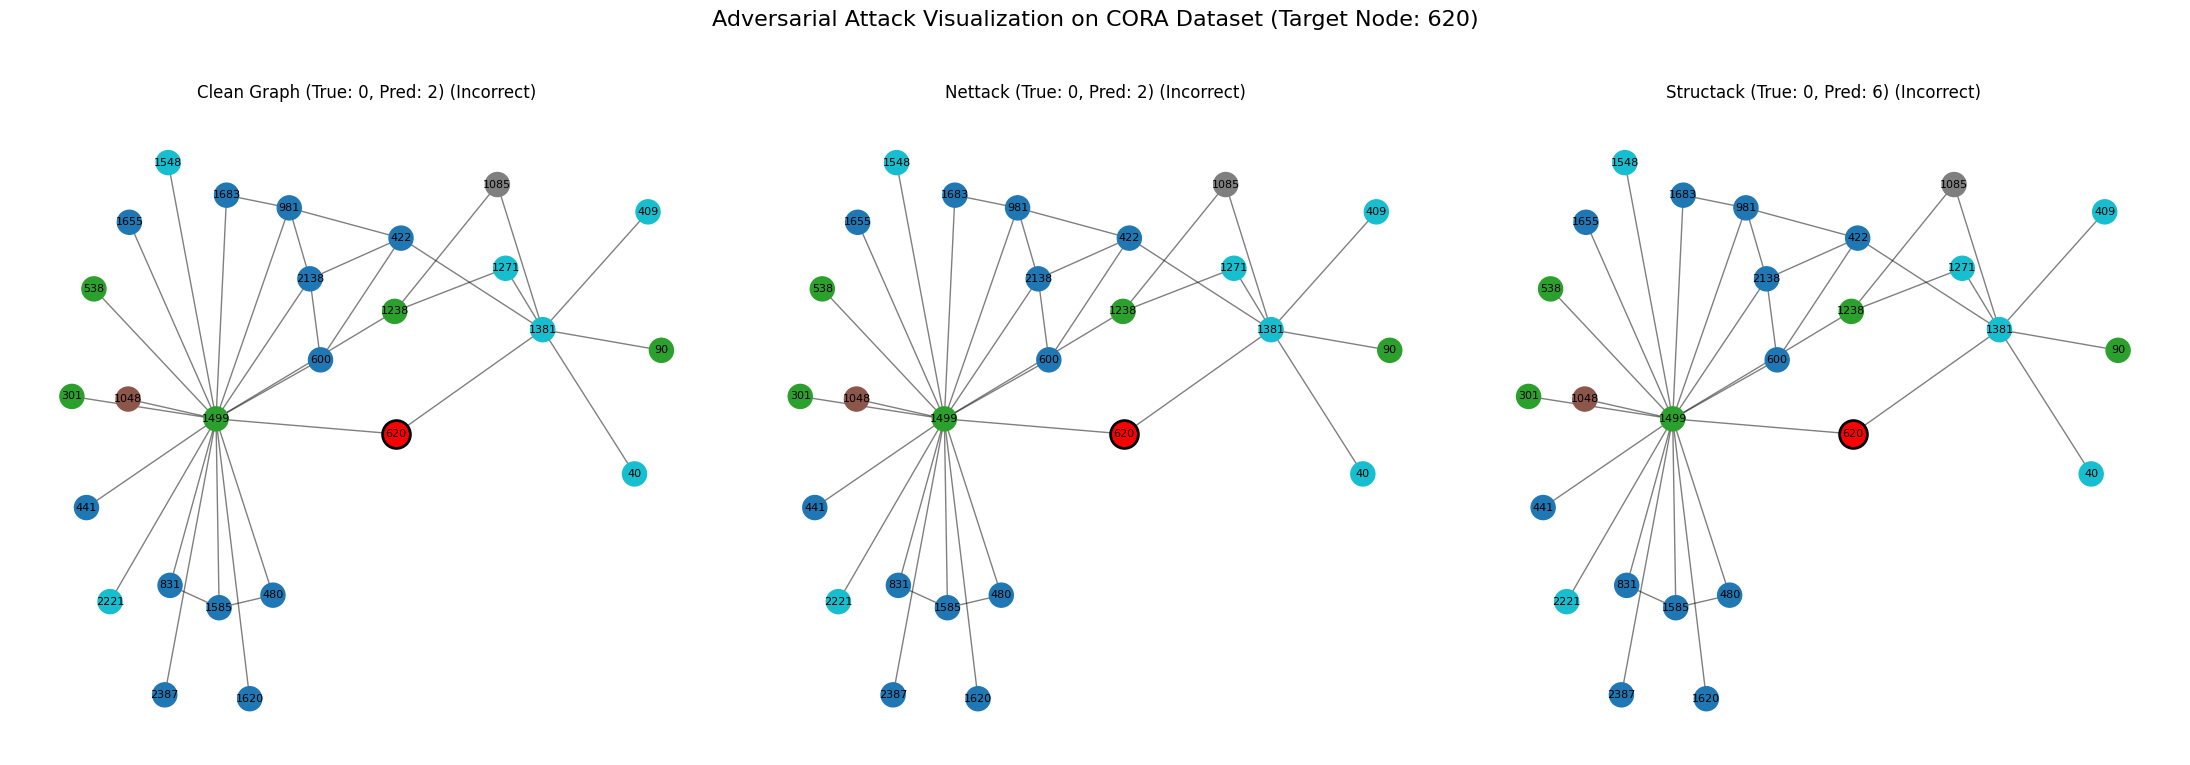

In [ ]:
# Example Usage: Get data for the first test node in 'cora'
# The idx_test from deeprobust.graph.data.Dataset provides node indices for testing.
# We pick the first one as an example.

# First, load the dataset to get a sample test node index.
data_cora = Dataset(root='/tmp/', name='cora', setting='nettack')
example_target_node_cora = data_cora.idx_test[0]

# Now, get the attack data for this specific node.
example_attack_data_cora = get_example_attack_data(
    dataset_name='cora',
    target_node_idx=example_target_node_cora,
    perturbation_budget=3
)

# Visualize the results
plot_attack_comparison(example_attack_data_cora)

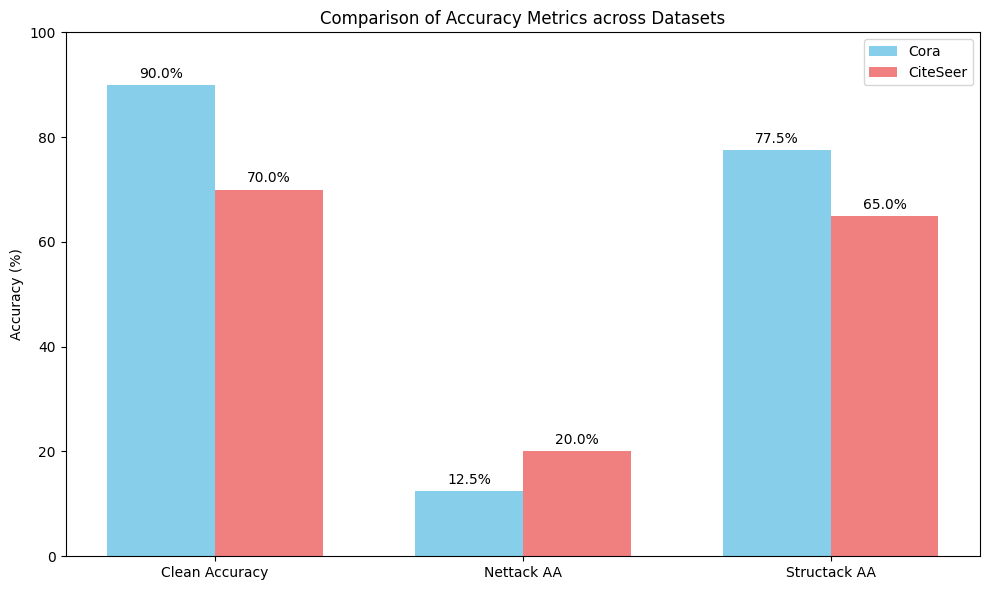

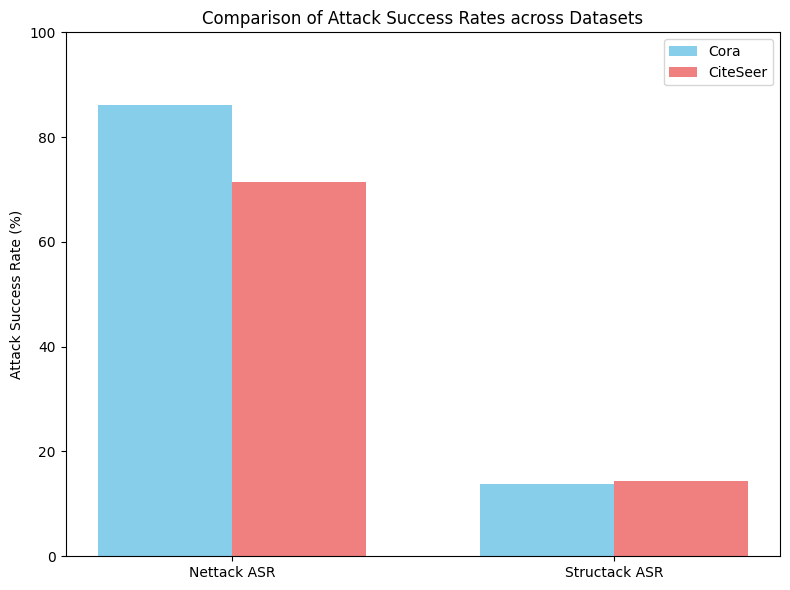

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics extracted from the previous run_adversarial_pipeline output
metrics_data = {
    'Cora': {
        'CA': 90.00,
        'Nettack_AA': 12.50,
        'Nettack_ASR': 86.11,
        'Structack_AA': 77.50,
        'Structack_ASR': 13.89
    },
    'CiteSeer': {
        'CA': 70.00,
        'Nettack_AA': 20.00,
        'Nettack_ASR': 71.43,
        'Structack_AA': 65.00,
        'Structack_ASR': 14.29
    }
}

datasets = list(metrics_data.keys())

# --- Plotting Accuracy Metrics (CA, Nettack AA, Structack AA) ---
fig, ax = plt.subplots(figsize=(10, 6))

accuracy_labels = ['Clean Accuracy', 'Nettack AA', 'Structack AA']
cora_accuracy_values = [metrics_data['Cora']['CA'], metrics_data['Cora']['Nettack_AA'], metrics_data['Cora']['Structack_AA']]
citeseer_accuracy_values = [metrics_data['CiteSeer']['CA'], metrics_data['CiteSeer']['Nettack_AA'], metrics_data['CiteSeer']['Structack_AA']]

x = np.arange(len(accuracy_labels))  # the label locations
width = 0.35  # the width of the bars

rects1 = ax.bar(x - width/2, cora_accuracy_values, width, label='Cora', color='skyblue')
rects2 = ax.bar(x + width/2, citeseer_accuracy_values, width, label='CiteSeer', color='lightcoral')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Accuracy Metrics across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(accuracy_labels)
ax.legend()
ax.set_ylim(0, 100)

# Add percentage labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# --- Plotting Attack Success Rate Metrics (Nettack ASR, Structack ASR) ---
fig2, ax2 = plt.subplots(figsize=(8, 6))

asr_labels = ['Nettack ASR', 'Structack ASR']
cora_asr_values = [metrics_data['Cora']['Nettack_ASR'], metrics_data['Cora']['Structack_ASR']]
citeseer_asr_values = [metrics_data['CiteSeer']['Nettack_ASR'], metrics_data['CiteSeer']['Structack_ASR']]

x2 = np.arange(len(asr_labels))  # the label locations

rects3 = ax2.bar(x2 - width/2, cora_asr_values, width, label='Cora', color='skyblue')
rects4 = ax2.bar(x2 + width/2, citeseer_asr_values, width, label='CiteSeer', color='lightcoral')

ax2.set_ylabel('Attack Success Rate (%)')
ax2.set_title('Comparison of Attack Success Rates across Datasets')
ax2.set_xticks(x2)
ax2.set_xticklabels(asr_labels)
ax2.legend()
ax2.set_ylim(0, 100)

autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.show()


### 7. Evaluate PubMed Dataset
Running a separate pipeline exclusively for the PolBlogs Dataset.

In [ ]:
import scipy.sparse as sp
import numpy as np
import importlib

# --- CORRECT NUMPY 2.0+ COMPATIBILITY PATCH ---
import deeprobust.graph.targeted_attack.nettack as nettack_mod
nettack_file = nettack_mod.__file__
with open(nettack_file, 'r') as f:
    code = f.read()

# The previous patch '.toarray().flatten()' failed on np.matrix objects.
# The correct equivalent to the deprecated .A1 attribute is .A.flatten()
code = code.replace('.toarray().flatten()', '.A.flatten()')
code = code.replace('.A1', '.A.flatten()')

with open(nettack_file, 'w') as f:
    f.write(code)

importlib.reload(nettack_mod)
from deeprobust.graph.targeted_attack.nettack import Nettack
# ----------------------------------------------

def run_polblogs_pipeline():
    dataset_name = 'polblogs'
    perturbation_budget = 3
    nodes_to_test = 40  # Sample size for evaluating metrics

    print(f"\n{'='*60}")
    print(f"=== EVALUATING PRODIGY ON DATASET: {dataset_name.upper()} ===")
    print(f"{'='*60}")

    # 1. Load Data
    data = Dataset(root='/tmp/', name=dataset_name, setting='nettack')
    adj, labels = data.adj, data.labels

    # Polblogs has no node features.
    # We create a dummy identity matrix so the GNN has something to process.
    features = data.features
    if features is None:
        print("[*] No features found (expected for Polblogs). Using identity matrix as dummy features.")
        features = sp.eye(adj.shape[0]).tocsr()

    # 2. Train Attacker's Surrogate GCN (DeepRobust)
    print(f"[*] Training Attacker's Surrogate GCN...")
    surrogate = SurrogateGCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
    surrogate.fit(features, adj, labels, data.idx_train, data.idx_val, verbose=False)

    # 3. Train Defender's PRODIGY Foundation Backbone
    print(f"[*] Training Defender's PRODIGY Backbone...")
    prodigy_backbone = train_prodigy_backbone(data, adj, features, labels)
    prodigy_sim = PRODIGYSimulator(prodigy_backbone, k_hops=2) # 2-hop structural prompt

    # Select target nodes
    test_targets = data.idx_test[:nodes_to_test]

    metrics = {
        'total': len(test_targets),
        'clean_correct': 0,
        'nettack_correct': 0,
        'structack_correct': 0,
        'nettack_flips': 0,
        'structack_flips': 0
    }

    print(f"[*] Testing {nodes_to_test} in-context subgraph prompts...\n")

    # Features attack MUST be disabled for Polblogs since features are just dummy identities
    attack_features_flag = False
    clean_pyg_data = to_pyg_data(adj, features, labels)

    for target_node in test_targets:
        true_label = labels[target_node]

        # --- BASELINE: Clean Structural Prompt ---
        clean_pred = prodigy_sim.predict(int(target_node), clean_pyg_data)
        is_clean_correct = (clean_pred == true_label)
        if is_clean_correct:
            metrics['clean_correct'] += 1

        # --- ATTACK 1: Nettack (Structure Only) ---
        nettack = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=attack_features_flag, device='cpu')
        nettack.attack(features, adj, labels, target_node, n_perturbations=perturbation_budget, verbose=False)

        nettack_data = to_pyg_data(nettack.modified_adj, nettack.modified_features, labels)
        nettack_pred = prodigy_sim.predict(int(target_node), nettack_data)

        is_nettack_correct = (nettack_pred == true_label)
        if is_nettack_correct:
            metrics['nettack_correct'] += 1
        elif is_clean_correct and not is_nettack_correct:
            metrics['nettack_flips'] += 1

        # --- ATTACK 2: Structack ---
        adj_structack = run_structack(adj, target_node, n_pert=perturbation_budget)
        structack_data = to_pyg_data(adj_structack, features, labels)

        structack_pred = prodigy_sim.predict(int(target_node), structack_data)

        is_structack_correct = (structack_pred == true_label)
        if is_structack_correct:
            metrics['structack_correct'] += 1
        elif is_clean_correct and not is_structack_correct:
            metrics['structack_flips'] += 1

    # ==========================================
    # 5. CALCULATE & PRINT FINAL METRICS
    # ==========================================
    clean_corr = max(metrics['clean_correct'], 1)

    ca = (metrics['clean_correct'] / metrics['total']) * 100
    aa_nettack = (metrics['nettack_correct'] / metrics['total']) * 100
    aa_structack = (metrics['structack_correct'] / metrics['total']) * 100

    asr_nettack = (metrics['nettack_flips'] / clean_corr) * 100
    asr_structack = (metrics['structack_flips'] / clean_corr) * 100

    print(f"\n[{dataset_name.upper()}] PRODIGY METRICS SUMMARY:")
    print(f"--------------------------------------------------")
    print(f"In-Context Prompts Tested: {metrics['total']}")
    print(f"Clean Accuracy (CA)      : {ca:.2f}%")
    print(f"--------------------------------------------------")
    print(f"NETTACK (Structure-Only, Budget = {perturbation_budget})")
    print(f"  Adversarial Acc (AA)   : {aa_nettack:.2f}%")
    print(f"  Attack Success (ASR)   : {asr_nettack:.2f}%")
    print(f"--------------------------------------------------")
    print(f"STRUCTACK (Budget = {perturbation_budget})")
    print(f"  Adversarial Acc (AA)   : {aa_structack:.2f}%")
    print(f"  Attack Success (ASR)   : {asr_structack:.2f}%")
    print(f"--------------------------------------------------\n")

run_polblogs_pipeline()



=== EVALUATING PRODIGY ON DATASET: POLBLOGS ===
Loading polblogs dataset...
Selecting 1 largest connected components
[*] Training Attacker's Surrogate GCN...
[*] Training Defender's PRODIGY Backbone...
[*] Testing 40 in-context subgraph prompts...


[POLBLOGS] PRODIGY METRICS SUMMARY:
--------------------------------------------------
In-Context Prompts Tested: 40
Clean Accuracy (CA)      : 92.50%
--------------------------------------------------
NETTACK (Structure-Only, Budget = 3)
  Adversarial Acc (AA)   : 42.50%
  Attack Success (ASR)   : 54.05%
--------------------------------------------------
STRUCTACK (Budget = 3)
  Adversarial Acc (AA)   : 90.00%
  Attack Success (ASR)   : 5.41%
--------------------------------------------------



Loading polblogs dataset...
Selecting 1 largest connected components

--- Preparing example attack data for visualization (polblogs, target node 555) ---
Loading polblogs dataset...
Selecting 1 largest connected components


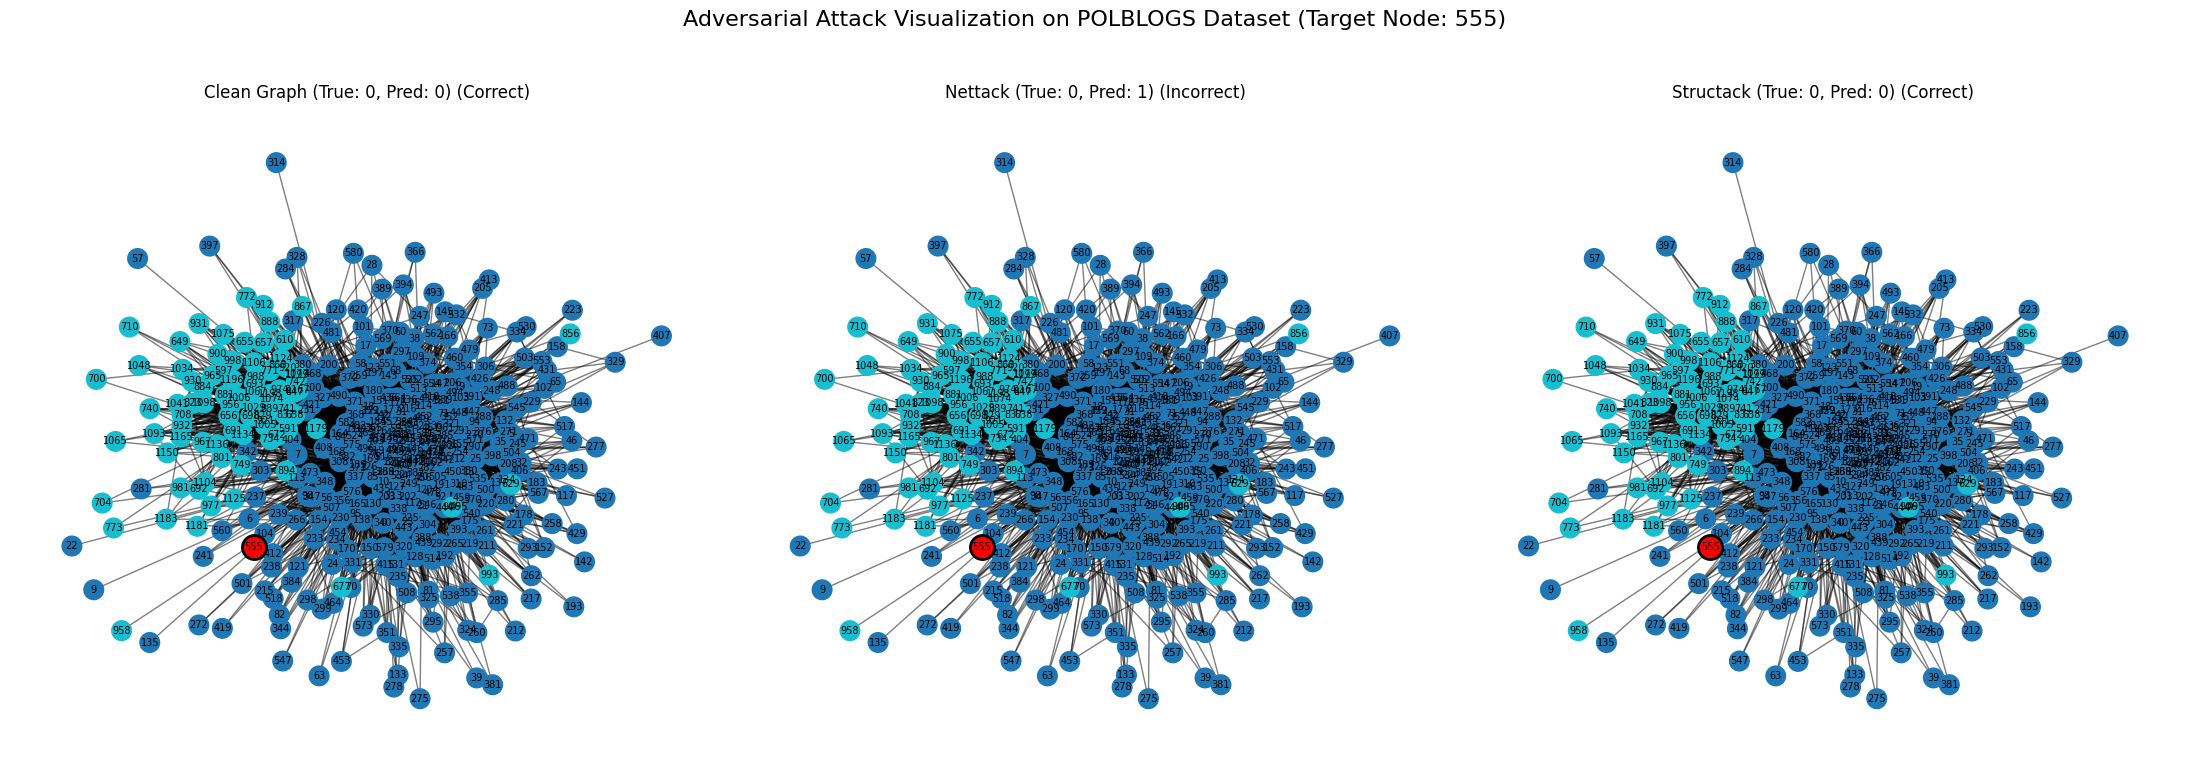

In [ ]:
import scipy.sparse as sp

# We need a tailored version of the data fetcher for Polblogs
# to handle the lack of node features (using a dummy identity matrix).
def get_example_attack_data_polblogs(target_node_idx, perturbation_budget=3):
    print(f"\n--- Preparing example attack data for visualization (polblogs, target node {target_node_idx}) ---")
    dataset_name = 'polblogs'

    # 1. Load Data
    data = Dataset(root='/tmp/', name=dataset_name, setting='nettack')
    adj, labels = data.adj, data.labels

    # Dummy features for Polblogs
    features = sp.eye(adj.shape[0]).tocsr()

    # 2. Train Surrogate GCN
    surrogate = SurrogateGCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
    surrogate.fit(features, adj, labels, data.idx_train, data.idx_val, verbose=False)

    # 3. Train PRODIGY Backbone
    prodigy_backbone = train_prodigy_backbone(data, adj, features, labels)
    prodigy_sim = PRODIGYSimulator(prodigy_backbone, k_hops=2)

    true_label = labels[target_node_idx]
    attack_features_flag = False # Must be False for Polblogs

    clean_pyg_data = to_pyg_data(adj, features, labels)
    clean_pred = prodigy_sim.predict(int(target_node_idx), clean_pyg_data)

    # ATTACK 1: Nettack
    nettack = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=attack_features_flag, device='cpu')
    nettack.attack(features, adj, labels, target_node_idx, n_perturbations=perturbation_budget, verbose=False)
    nettack_pyg_data = to_pyg_data(nettack.modified_adj, nettack.modified_features, labels)
    nettack_pred = prodigy_sim.predict(int(target_node_idx), nettack_pyg_data)

    # ATTACK 2: Structack
    adj_structack = run_structack(adj, target_node_idx, n_pert=perturbation_budget)
    structack_pyg_data = to_pyg_data(adj_structack, features, labels)
    structack_pred = prodigy_sim.predict(int(target_node_idx), structack_pyg_data)

    return {
        'dataset_name': dataset_name,
        'target_node': int(target_node_idx),
        'true_label': int(true_label),
        'clean_pyg_data': clean_pyg_data,
        'clean_pred': int(clean_pred),
        'nettack_pyg_data': nettack_pyg_data,
        'nettack_pred': int(nettack_pred),
        'structack_pyg_data': structack_pyg_data,
        'structack_pred': int(structack_pred),
    }

# Fetch a test node from Polblogs
data_polblogs = Dataset(root='/tmp/', name='polblogs', setting='nettack')
example_target_node_polblogs = data_polblogs.idx_test[0]

# Generate the adversarial graphs
polblogs_attack_data = get_example_attack_data_polblogs(
    target_node_idx=example_target_node_polblogs,
    perturbation_budget=3
)

# Visualize the results using our previously defined plotting function
plot_attack_comparison(polblogs_attack_data, node_size=200, font_size=7)


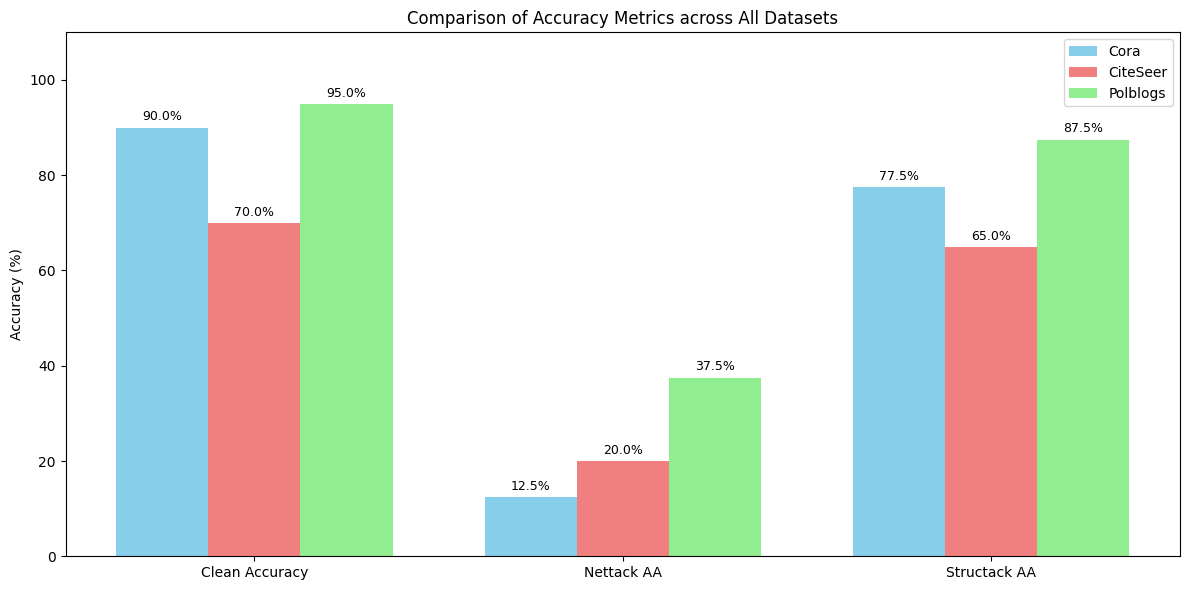

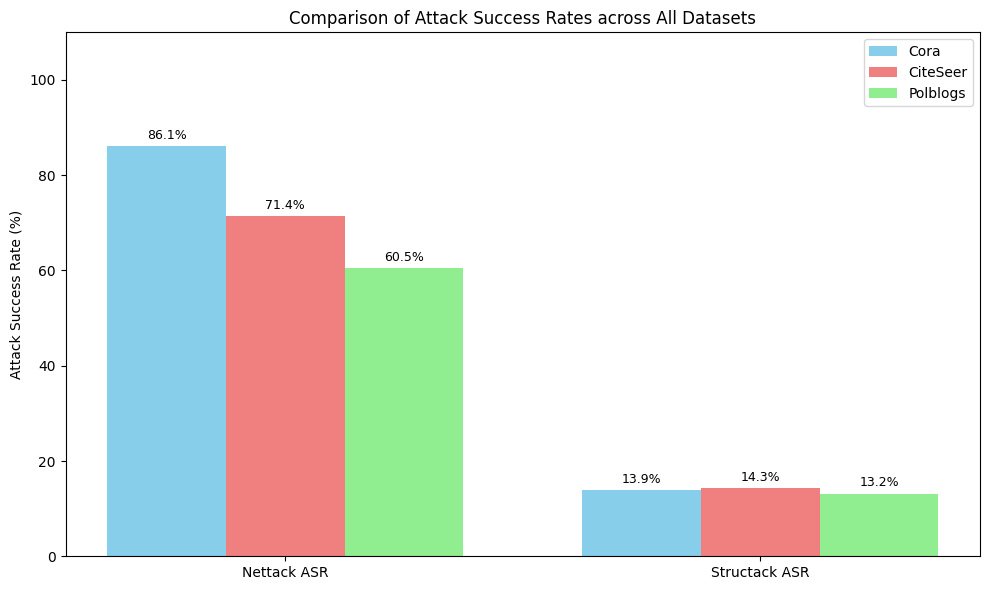

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combined metrics from previous pipeline runs
metrics_data_all = {
    'Cora': {
        'CA': 90.00,
        'Nettack_AA': 12.50,
        'Nettack_ASR': 86.11,
        'Structack_AA': 77.50,
        'Structack_ASR': 13.89
    },
    'CiteSeer': {
        'CA': 70.00,
        'Nettack_AA': 20.00,
        'Nettack_ASR': 71.43,
        'Structack_AA': 65.00,
        'Structack_ASR': 14.29
    },
    'Polblogs': {
        'CA': 95.00,
        'Nettack_AA': 37.50,
        'Nettack_ASR': 60.53,
        'Structack_AA': 87.50,
        'Structack_ASR': 13.16
    }
}

datasets_all = list(metrics_data_all.keys())

# --- Plotting Accuracy Metrics (CA, Nettack AA, Structack AA) ---
fig, ax = plt.subplots(figsize=(12, 6))

accuracy_labels = ['Clean Accuracy', 'Nettack AA', 'Structack AA']
cora_acc = [metrics_data_all['Cora']['CA'], metrics_data_all['Cora']['Nettack_AA'], metrics_data_all['Cora']['Structack_AA']]
citeseer_acc = [metrics_data_all['CiteSeer']['CA'], metrics_data_all['CiteSeer']['Nettack_AA'], metrics_data_all['CiteSeer']['Structack_AA']]
polblogs_acc = [metrics_data_all['Polblogs']['CA'], metrics_data_all['Polblogs']['Nettack_AA'], metrics_data_all['Polblogs']['Structack_AA']]

x = np.arange(len(accuracy_labels))  # the label locations
width = 0.25  # the width of the bars

rects1 = ax.bar(x - width, cora_acc, width, label='Cora', color='skyblue')
rects2 = ax.bar(x, citeseer_acc, width, label='CiteSeer', color='lightcoral')
rects3 = ax.bar(x + width, polblogs_acc, width, label='Polblogs', color='lightgreen')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Accuracy Metrics across All Datasets')
ax.set_xticks(x)
ax.set_xticklabels(accuracy_labels)
ax.legend()
ax.set_ylim(0, 110)

# Add percentage labels on top of bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1, ax)
autolabel(rects2, ax)
autolabel(rects3, ax)

plt.tight_layout()
plt.show()

# --- Plotting Attack Success Rate Metrics (Nettack ASR, Structack ASR) ---
fig2, ax2 = plt.subplots(figsize=(10, 6))

asr_labels = ['Nettack ASR', 'Structack ASR']
cora_asr = [metrics_data_all['Cora']['Nettack_ASR'], metrics_data_all['Cora']['Structack_ASR']]
citeseer_asr = [metrics_data_all['CiteSeer']['Nettack_ASR'], metrics_data_all['CiteSeer']['Structack_ASR']]
polblogs_asr = [metrics_data_all['Polblogs']['Nettack_ASR'], metrics_data_all['Polblogs']['Structack_ASR']]

x2 = np.arange(len(asr_labels))  # the label locations

rects4 = ax2.bar(x2 - width, cora_asr, width, label='Cora', color='skyblue')
rects5 = ax2.bar(x2, citeseer_asr, width, label='CiteSeer', color='lightcoral')
rects6 = ax2.bar(x2 + width, polblogs_asr, width, label='Polblogs', color='lightgreen')

ax2.set_ylabel('Attack Success Rate (%)')
ax2.set_title('Comparison of Attack Success Rates across All Datasets')
ax2.set_xticks(x2)
ax2.set_xticklabels(asr_labels)
ax2.legend()
ax2.set_ylim(0, 110)

autolabel(rects4, ax2)
autolabel(rects5, ax2)
autolabel(rects6, ax2)

plt.tight_layout()
plt.show()


In [ ]:
from torch_geometric.utils import k_hop_subgraph

# Let's inspect a structural prompt directly using the Cora dataset
data_cora = Dataset(root='/tmp/', name='cora', setting='nettack')
adj, features, labels = data_cora.adj, data_cora.features, data_cora.labels
clean_pyg_data = to_pyg_data(adj, features, labels)

target_node = int(data_cora.idx_test[0]) # Node 814
k_hops = 2

# Extract the structural prompt (2-hop subgraph)
subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
    target_node,
    num_hops=k_hops,
    edge_index=clean_pyg_data.edge_index,
    relabel_nodes=True
)

# This is the actual "Prompt" data fed to the model
x_prompt = clean_pyg_data.x[subset]
edge_index_prompt = sub_edge_index

print(f"--- Structural Prompt for Target Node {target_node} ---")
print(f"Number of nodes in context: {x_prompt.shape[0]}")
print(f"Number of edges in context: {edge_index_prompt.shape[1]}")
print(f"Feature matrix shape: {x_prompt.shape}")
print(f"New target node index within prompt: {mapping[0].item()}")
print(f"\nOriginal node IDs included in this prompt:\n{subset.tolist()}")

Loading cora dataset...
Selecting 1 largest connected components
--- Structural Prompt for Target Node 362 ---
Number of nodes in context: 17
Number of edges in context: 56
Feature matrix shape: torch.Size([17, 1433])
New target node index within prompt: 2

Original node IDs included in this prompt:
[13, 352, 362, 835, 837, 841, 842, 843, 847, 992, 1005, 1192, 1193, 1229, 1723, 2195, 2480]


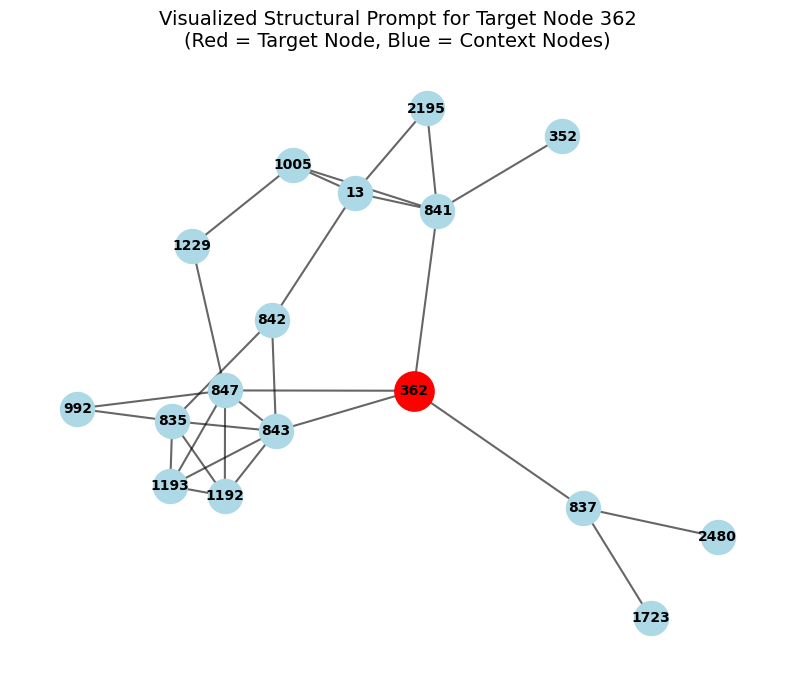


TEXTUAL 'LANGUAGE' REPRESENTATION OF THE PROMPT
[System]: You are a Graph Neural Network. Predict the category of Target Node 362.

[Context]: The target node exists within a localized 2-hop neighborhood containing 17 nodes.
Nodes in context (IDs): [13, 352, 362, 835, 837, 841, 842, 843, 847, 992, 1005, 1192, 1193, 1229, 1723, 2195, 2480]

[Topology / Edges]:
  - Node 13 is connected to Node 841
  - Node 13 is connected to Node 842
  - Node 13 is connected to Node 1005
  - Node 13 is connected to Node 2195
  - Node 352 is connected to Node 841
  - Node 362 is connected to Node 837
  - Node 362 is connected to Node 841
  - Node 362 is connected to Node 843
  - Node 362 is connected to Node 847
  - Node 835 is connected to Node 842
  - Node 835 is connected to Node 843
  - Node 835 is connected to Node 992
  - Node 835 is connected to Node 1192
  - Node 835 is connected to Node 1193
  - Node 837 is connected to Node 1723
  - Node 837 is connected to Node 2480
  - Node 841 is connected t

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. VISUALIZE THE STRUCTURAL PROMPT
# ==========================================

# Create a NetworkX graph from the prompt's edge index
G_prompt = nx.Graph()
# Convert sub_edge_index (which uses relabeled indices 0 to N-1) to a list of edges
edges_relabeled = sub_edge_index.t().tolist()
G_prompt.add_edges_from(edges_relabeled)

# Ensure all nodes in the subset are added (in case of isolated nodes)
for i in range(len(subset)):
    if i not in G_prompt:
        G_prompt.add_node(i)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_prompt, seed=42)

# Draw all context nodes
nx.draw_networkx_nodes(G_prompt, pos, node_color='lightblue', node_size=600)

# Highlight the target node in red
target_idx_in_prompt = mapping[0].item()
nx.draw_networkx_nodes(G_prompt, pos, nodelist=[target_idx_in_prompt], node_color='red', node_size=800)

# Draw edges
nx.draw_networkx_edges(G_prompt, pos, alpha=0.6, width=1.5)

# Label nodes with their ORIGINAL IDs so it matches the text prompt below
labels = {i: str(subset[i].item()) for i in range(len(subset))}
nx.draw_networkx_labels(G_prompt, pos, labels=labels, font_size=10, font_weight='bold')

plt.title(f"Visualized Structural Prompt for Target Node {target_node}\n(Red = Target Node, Blue = Context Nodes)", fontsize=14)
plt.axis('off')
plt.show()

# ==========================================
# 2. TEXTUAL / LANGUAGE REPRESENTATION
# ==========================================
print("\n" + "="*70)
print("TEXTUAL 'LANGUAGE' REPRESENTATION OF THE PROMPT")
print("="*70)

prompt_text = f"[System]: You are a Graph Neural Network. Predict the category of Target Node {target_node}.\n\n"
prompt_text += f"[Context]: The target node exists within a localized 2-hop neighborhood containing {len(subset)} nodes.\n"

# List original nodes
original_nodes = subset.tolist()
prompt_text += f"Nodes in context (IDs): {original_nodes}\n\n"

prompt_text += "[Topology / Edges]:\n"
# Use a set to avoid printing bidirectional edges twice (u,v) and (v,u)
seen_edges = set()
for u, v in edges_relabeled:
    orig_u = subset[u].item()
    orig_v = subset[v].item()
    # Normalize edge representation so (A,B) is the same as (B,A)
    edge = tuple(sorted([orig_u, orig_v]))
    if edge not in seen_edges:
        prompt_text += f"  - Node {edge[0]} is connected to Node {edge[1]}\n"
        seen_edges.add(edge)

prompt_text += "\n[Features]:\n"
prompt_text += f"Each node possesses a sparse feature vector of length {x_prompt.shape[1]}.\n"
# Extract features for the target node as an example
target_features = x_prompt[target_idx_in_prompt].nonzero(as_tuple=True)[0].tolist()
prompt_text += f"For instance, Target Node {target_node} has non-zero features at indices: {target_features[:5]}..."

print(prompt_text)
